# 01 Data Cleaning and Exploration

This notebook documents the data cleaning and exploratory analysis stage of the river dissolved oxygen prediction project.

Datasets used:
- AquaSensor data from Derwent 13, Derwent 13-50, and Derwent 21
- Government / Environment Agency data
- Weather data

The cleaned outputs are used later for preprocessing, model training, live prediction, and recent unused-data evaluation.

Cell 1 — Markdown
Cell 2 — Imports
Cell 3 — Paths
Cell 4 — Check raw files
Cell 5 — Load cleaned data
Cell 6 — Cleaning report
Cell 7 — AquaSensor preview
Cell 8 — AquaSensor summary
Cell 9 — Date ranges
Cell 10 — Sensor counts
Cell 11 — Missing values
Cell 12 — DO mg/L distribution
Cell 13 — DO % distribution
Cell 14 — Water temperature distribution
Cell 15 — DO over time by sensor
Cell 16 — DO % over time by sensor
Cell 17 — Weather Overview
Cell 18 — Weather plots
Cell 19 — Government data overview
Cell 20 — Summary
    
    

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
AQUASENSOR_DIR = "../data/raw/Aquasensor Data 1yr"
GOVT_DIR = "../data/raw/Govt.Data"
WEATHER_FILE = "../data/raw/weather_data.csv"

PROCESSED_DIR = "../data/processed"

AQUASENSOR_CLEANED = "../data/processed/aquasensor_cleaned.csv"
GOVT_CLEANED = "../data/processed/govt_cleaned.csv"
WEATHER_CLEANED = "../data/processed/weather_cleaned.csv"
CLEANING_REPORT = "../data/processed/data_cleaning_report.csv"

In [3]:
print("AquaSensor files:")
for f in glob.glob(os.path.join(AQUASENSOR_DIR, "*.csv")):
    print(f)

print("\nGovernment files:")
for f in glob.glob(os.path.join(GOVT_DIR, "*.csv")):
    print(f)

print("\nWeather file exists:", os.path.exists(WEATHER_FILE))

AquaSensor files:
../data/raw/Aquasensor Data 1yr\022 sensorreadings (2).csv
../data/raw/Aquasensor Data 1yr\941115 sensorreadings.csv
../data/raw/Aquasensor Data 1yr\941205 sensorreadings (1).csv

Government files:
../data/raw/Govt.Data\SHEAF_ABBEYDALE-HAMLET_E_202604-DISSOLVED OXYGEN-15min-Measured.csv
../data/raw/Govt.Data\SHEAF_ABBEYDALE-HAMLET_E_202604_all-measures.csv

Weather file exists: True


In [4]:
aquasensor = pd.read_csv(AQUASENSOR_CLEANED, parse_dates=["timestamp"])
govt = pd.read_csv(GOVT_CLEANED, parse_dates=["timestamp"])
weather = pd.read_csv(WEATHER_CLEANED, parse_dates=["timestamp"])
cleaning_report = pd.read_csv(CLEANING_REPORT)

print("AquaSensor shape:", aquasensor.shape)
print("Government shape:", govt.shape)
print("Weather shape:", weather.shape)

AquaSensor shape: (107974, 6)
Government shape: (8312, 8)
Weather shape: (21744, 4)


In [5]:
cleaning_report

,dataset,file,original_rows,cleaned_rows,removed_missing,removed_duplicates,removed_invalid_values
0,AquaSensor,022 sensorreadings (2).csv,42479,41460,0,1019,0
1,AquaSensor,941115 sensorreadings.csv,33690,33690,0,0,0
2,AquaSensor,941205 sensorreadings (1).csv,32830,32824,0,6,0
3,Government,SHEAF_ABBEYDALE-HAMLET_E_202604-DISSOLVED OXYG...,1039,1039,0,0,0
4,Government,SHEAF_ABBEYDALE-HAMLET_E_202604_all-measures.csv,7273,7273,0,0,0
5,Weather,weather_data.csv,21744,21744,0,0,0


In [6]:
aquasensor.head()

,timestamp,sensor_id,sensor_name,temperature,dissolved_oxygen_mgl,dissolved_oxygen_pct
0,2025-06-01 00:04:48,941115,Derwent 13-50,13.0,9.7,91.2
1,2025-06-01 00:16:44,941115,Derwent 13-50,12.9,9.7,91.1
2,2025-06-01 00:28:41,941115,Derwent 13-50,12.9,9.7,90.9
3,2025-06-01 00:40:37,941115,Derwent 13-50,12.8,9.7,90.7
4,2025-06-01 00:52:33,941115,Derwent 13-50,12.8,9.7,90.5


In [7]:
aquasensor.info()
aquasensor.describe()

<class 'pandas.DataFrame'>
RangeIndex: 107974 entries, 0 to 107973
Data columns (total 6 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   timestamp             107974 non-null  datetime64[us]
 1   sensor_id             107974 non-null  str           
 2   sensor_name           107974 non-null  str           
 3   temperature           107974 non-null  float64       
 4   dissolved_oxygen_mgl  107974 non-null  float64       
 5   dissolved_oxygen_pct  107974 non-null  float64       
dtypes: datetime64[us](1), float64(3), str(2)
memory usage: 6.8 MB


,timestamp,temperature,dissolved_oxygen_mgl,dissolved_oxygen_pct
count,107974,107974.000000,107974.000000,107974.000000
mean,2025-12-01 01:41:55.737529,9.628029,11.563135,100.047742
min,2023-10-30 00:00:00,0.000000,1.300000,11.800000
25%,2025-08-20 12:21:38.250000,7.000000,10.600000,96.200000
50%,2025-11-16 21:37:44,9.600000,11.400000,100.600000
75%,2026-03-11 17:58:43.250000,12.700000,12.800000,103.800000
max,2026-06-04 21:13:40,36.900000,21.800000,189.100000
std,NaN,3.426310,1.562476,9.336814


In [8]:
print("AquaSensor date range:")
print(aquasensor["timestamp"].min(), "to", aquasensor["timestamp"].max())

print("\nGovernment date range:")
print(govt["timestamp"].min(), "to", govt["timestamp"].max())

print("\nWeather date range:")
print(weather["timestamp"].min(), "to", weather["timestamp"].max())

AquaSensor date range:
2023-10-30 00:00:00 to 2026-06-04 21:13:40

Government date range:
2026-04-21 12:01:11 to 2026-06-03 20:01:11

Weather date range:
2024-01-01 00:00:00 to 2026-06-24 23:00:00


In [9]:
aquasensor["sensor_name"].value_counts()

sensor_name
Derwent 13       41460
Derwent 13-50    33690
Derwent 21       32824
Name: count, dtype: int64

In [10]:
print("AquaSensor missing values:")
display(aquasensor.isnull().sum())

print("\nGovernment missing values:")
display(govt.isnull().sum())

print("\nWeather missing values:")
display(weather.isnull().sum())

AquaSensor missing values:


timestamp               0
sensor_id               0
sensor_name             0
temperature             0
dissolved_oxygen_mgl    0
dissolved_oxygen_pct    0
dtype: int64


Government missing values:


measure            0
timestamp          0
date               0
value              0
completeness    8312
quality            0
qcode           8312
source_file        0
dtype: int64


Weather missing values:


timestamp            0
air_temperature_c    0
sunshine_wm2         0
cloud_cover_pct      0
dtype: int64

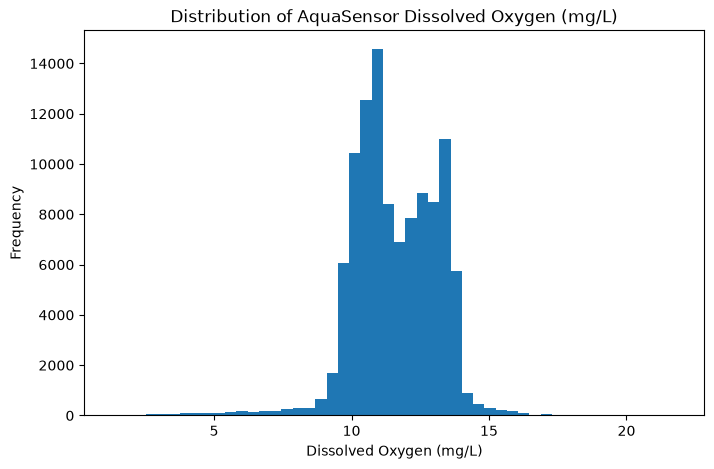

In [11]:
plt.figure(figsize=(8, 5))
plt.hist(aquasensor["dissolved_oxygen_mgl"], bins=50)
plt.xlabel("Dissolved Oxygen (mg/L)")
plt.ylabel("Frequency")
plt.title("Distribution of AquaSensor Dissolved Oxygen (mg/L)")
plt.show()

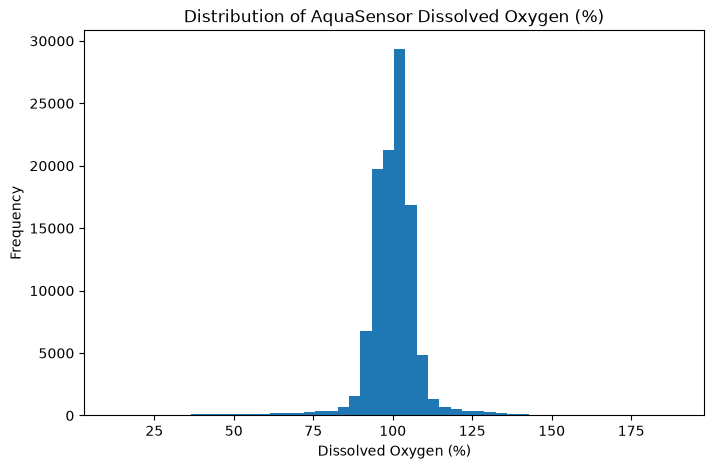

In [12]:
plt.figure(figsize=(8, 5))
plt.hist(aquasensor["dissolved_oxygen_pct"], bins=50)
plt.xlabel("Dissolved Oxygen (%)")
plt.ylabel("Frequency")
plt.title("Distribution of AquaSensor Dissolved Oxygen (%)")
plt.show()

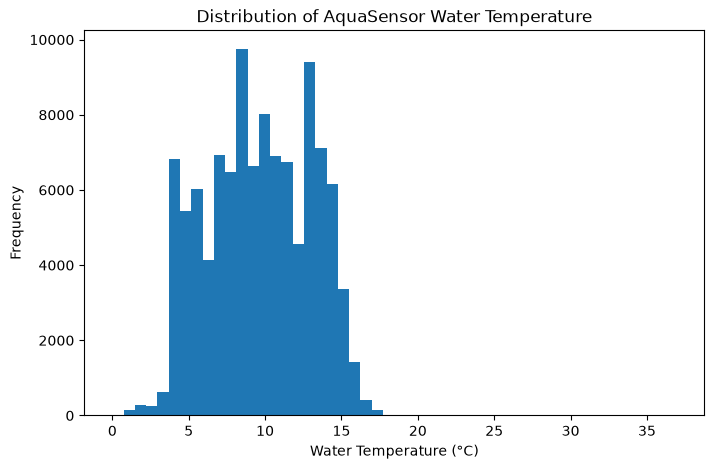

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(aquasensor["temperature"], bins=50)
plt.xlabel("Water Temperature (°C)")
plt.ylabel("Frequency")
plt.title("Distribution of AquaSensor Water Temperature")
plt.show()

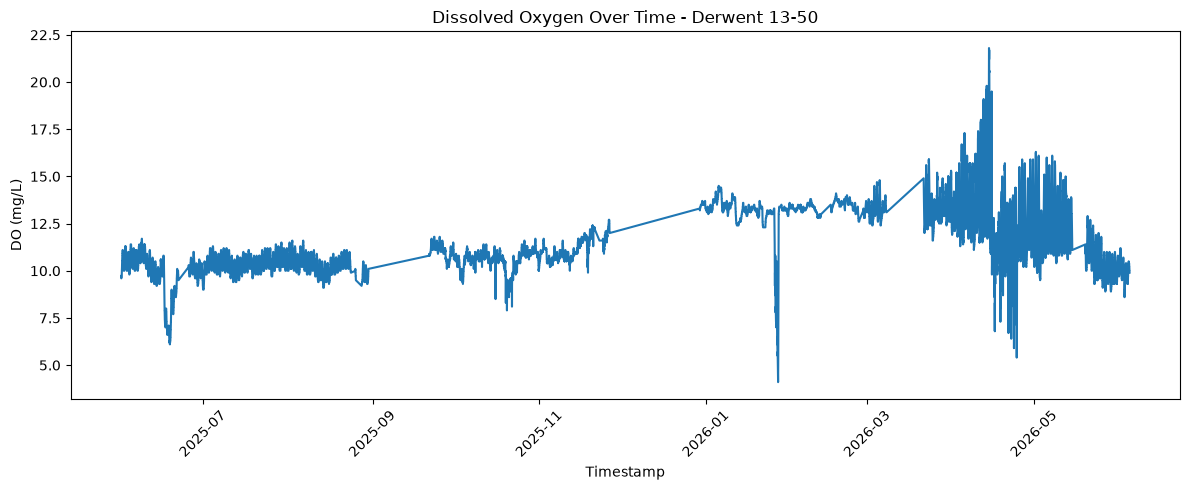

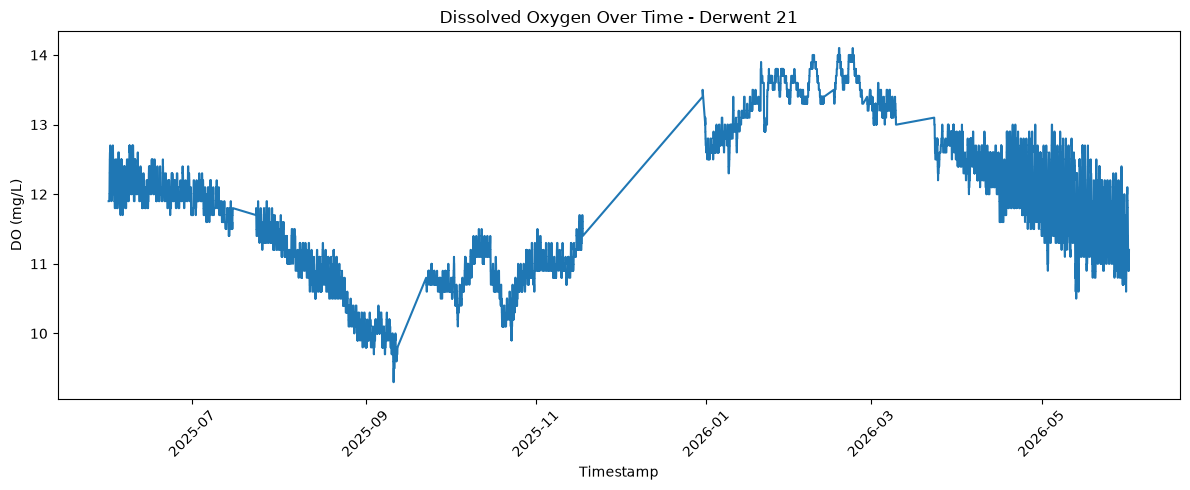

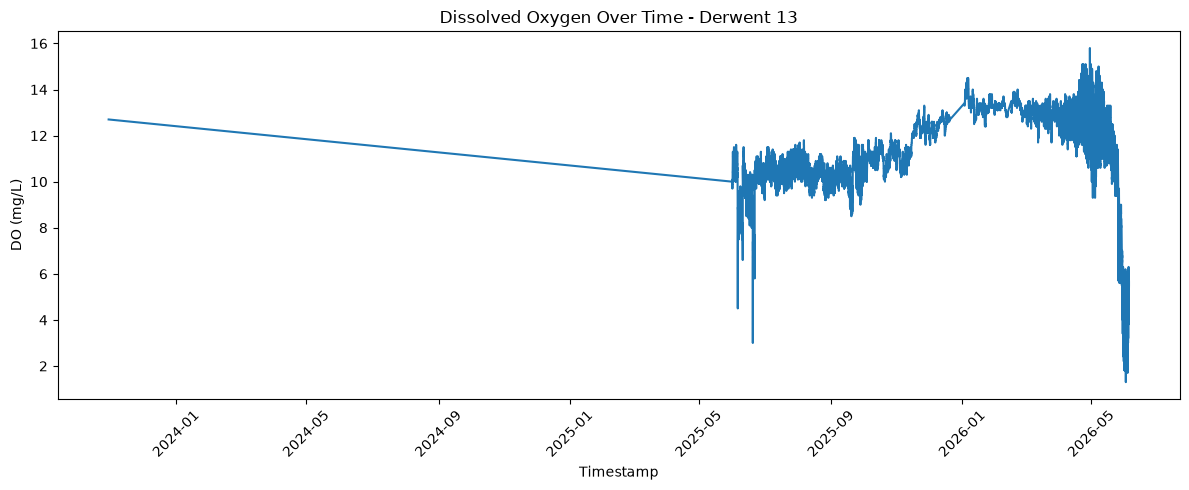

In [14]:
for sensor in aquasensor["sensor_name"].unique():
    sensor_df = aquasensor[aquasensor["sensor_name"] == sensor]

    plt.figure(figsize=(12, 5))
    plt.plot(sensor_df["timestamp"], sensor_df["dissolved_oxygen_mgl"])
    plt.xlabel("Timestamp")
    plt.ylabel("DO (mg/L)")
    plt.title(f"Dissolved Oxygen Over Time - {sensor}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

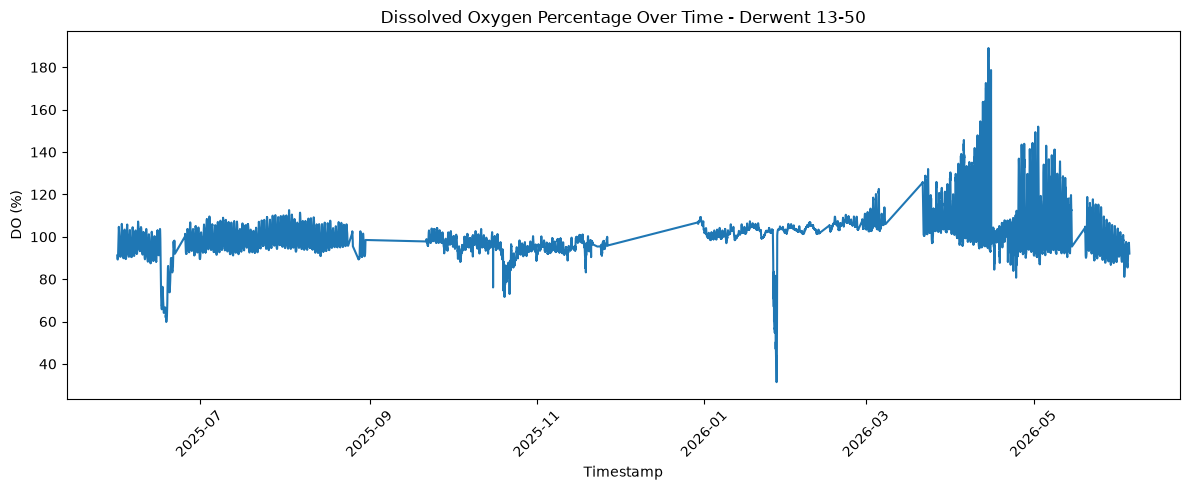

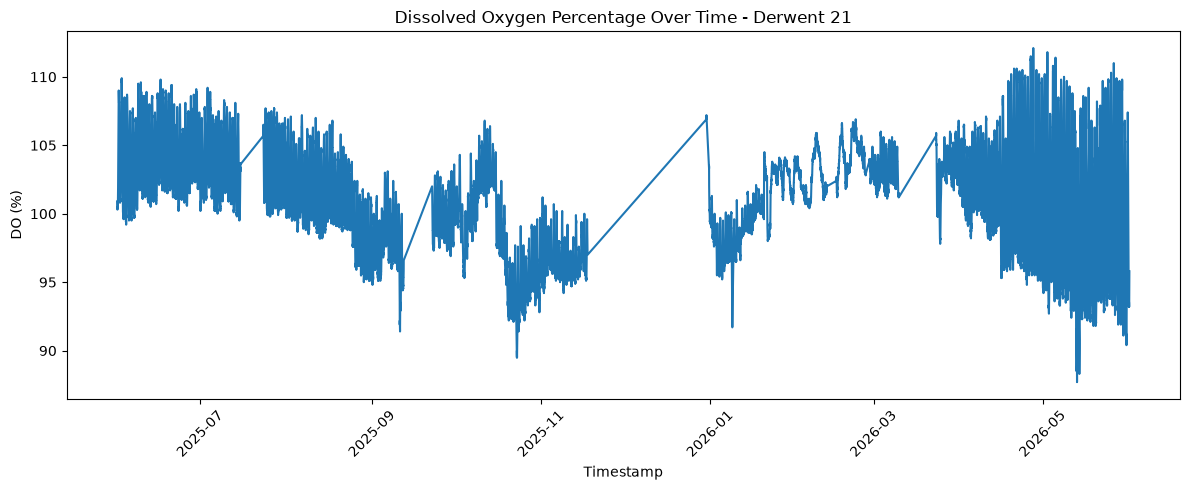

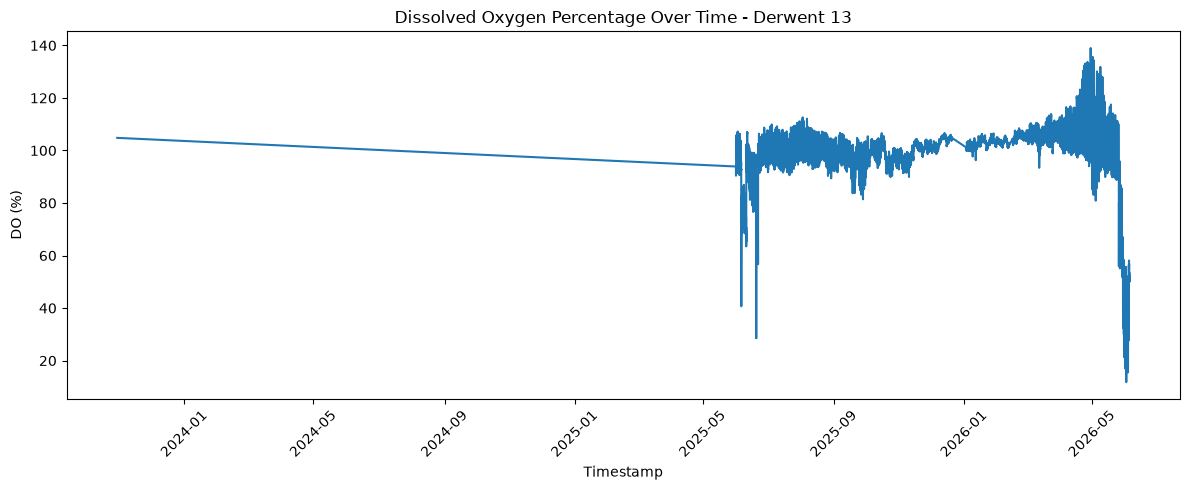

In [15]:
for sensor in aquasensor["sensor_name"].unique():
    sensor_df = aquasensor[aquasensor["sensor_name"] == sensor]

    plt.figure(figsize=(12, 5))
    plt.plot(sensor_df["timestamp"], sensor_df["dissolved_oxygen_pct"])
    plt.xlabel("Timestamp")
    plt.ylabel("DO (%)")
    plt.title(f"Dissolved Oxygen Percentage Over Time - {sensor}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [16]:
weather.head()
weather.describe()

,timestamp,air_temperature_c,sunshine_wm2,cloud_cover_pct
count,21744,21744.000000,21744.000000,21744.000000
mean,2025-03-28 23:30:00,9.433867,121.530491,74.554912
min,2024-01-01 00:00:00,-7.300000,0.000000,0.000000
25%,2024-08-14 11:45:00,5.300000,0.000000,48.000000
50%,2025-03-28 23:30:00,9.400000,6.000000,100.000000
75%,2025-11-10 11:15:00,13.100000,180.000000,100.000000
max,2026-06-24 23:00:00,28.700000,885.000000,100.000000
std,NaN,5.447426,190.886157,36.346798


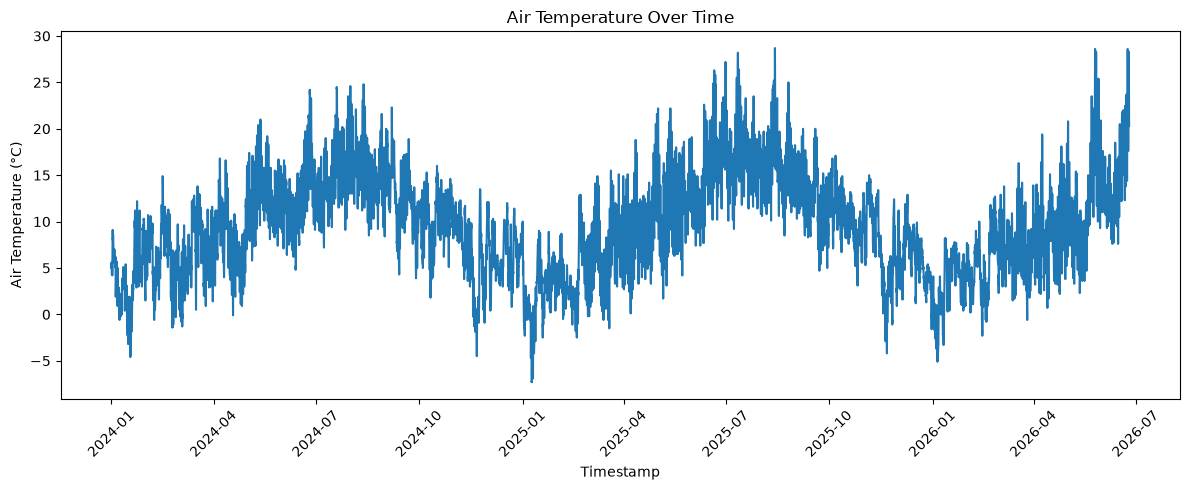

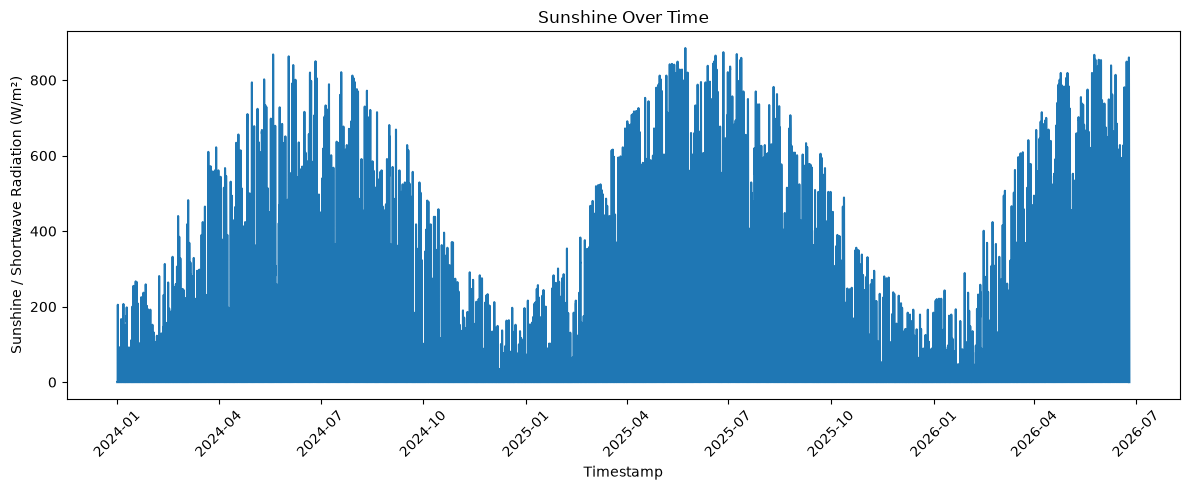

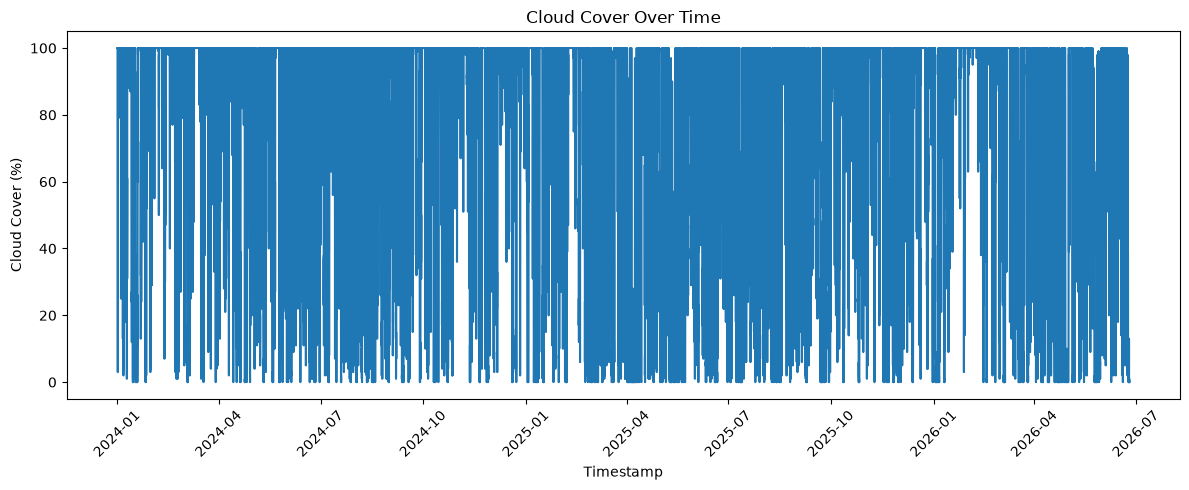

In [17]:
plt.figure(figsize=(12, 5))
plt.plot(weather["timestamp"], weather["air_temperature_c"])
plt.xlabel("Timestamp")
plt.ylabel("Air Temperature (°C)")
plt.title("Air Temperature Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(weather["timestamp"], weather["sunshine_wm2"])
plt.xlabel("Timestamp")
plt.ylabel("Sunshine / Shortwave Radiation (W/m²)")
plt.title("Sunshine Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(weather["timestamp"], weather["cloud_cover_pct"])
plt.xlabel("Timestamp")
plt.ylabel("Cloud Cover (%)")
plt.title("Cloud Cover Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
govt.head()
govt["source_file"].value_counts()

source_file
SHEAF_ABBEYDALE-HAMLET_E_202604_all-measures.csv                       7273
SHEAF_ABBEYDALE-HAMLET_E_202604-DISSOLVED OXYGEN-15min-Measured.csv    1039
Name: count, dtype: int64

## Summary

The data cleaning stage produced cleaned AquaSensor, Government, and weather datasets.

The AquaSensor data are used as the primary modelling dataset because the prediction targets are future dissolved oxygen values at the AquaSensor Derwent locations.

Weather data are used as environmental input features.

Government / Environment Agency data are cleaned and retained for comparison, context, and validation, but are not used as direct live prediction inputs because the monitoring station differs from the AquaSensor Derwent sites.